In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [3]:
# Number of rows and columns
df = pd.read_csv("../data/HR-Employee-Attrition-Data.csv")
print("Dataset Shape:", df.shape)

Dataset Shape: (1470, 35)


In [4]:
# List all column names
print("Columns:")
print(df.columns.tolist())

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
print("Attrition Value Counts:")
print(df['Attrition'].value_counts())
print()

print("Attrition Percentage:")
print(df['Attrition'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Attrition Value Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentage:
Attrition
No     83.88%
Yes    16.12%
Name: proportion, dtype: object


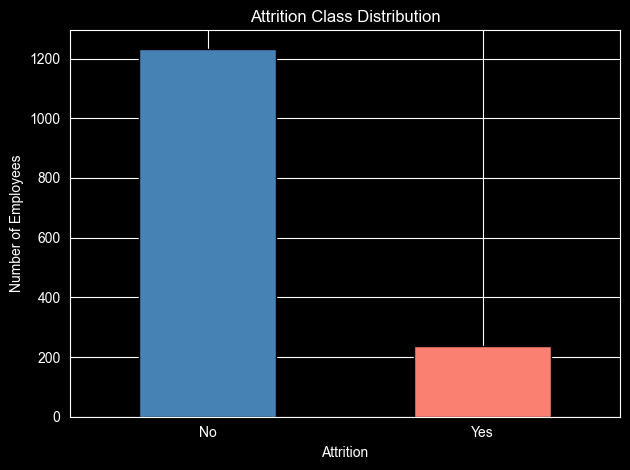

In [8]:
df['Attrition'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Attrition Class Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Attrition after conversion:")
print(df['Attrition'].value_counts())

Attrition after conversion:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [11]:
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

cols_to_drop = [col for col in cols_to_drop if col in df.columns]

df.drop(columns=cols_to_drop, inplace=True)

print("Dropped columns:", cols_to_drop)
print("New shape:", df.shape)

Dropped columns: []
New shape: (1470, 31)


In [12]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Categorical columns to encode:")
print(categorical_cols)

Categorical columns to encode:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [13]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [14]:
correlation_with_target = df.corr()['Attrition'].drop('Attrition')

correlation_sorted = correlation_with_target.abs().sort_values(ascending=False)

print("Top 15 features correlated with Attrition:")
print(correlation_sorted.head(15).round(4))

Top 15 features correlated with Attrition:
OverTime_Yes                        0.2461
MaritalStatus_Single                0.1754
TotalWorkingYears                   0.1711
JobLevel                            0.1691
YearsInCurrentRole                  0.1605
MonthlyIncome                       0.1598
Age                                 0.1592
JobRole_Sales Representative        0.1572
YearsWithCurrManager                0.1562
StockOptionLevel                    0.1371
YearsAtCompany                      0.1344
JobInvolvement                      0.1300
BusinessTravel_Travel_Frequently    0.1151
JobSatisfaction                     0.1035
EnvironmentSatisfaction             0.1034
Name: Attrition, dtype: float64


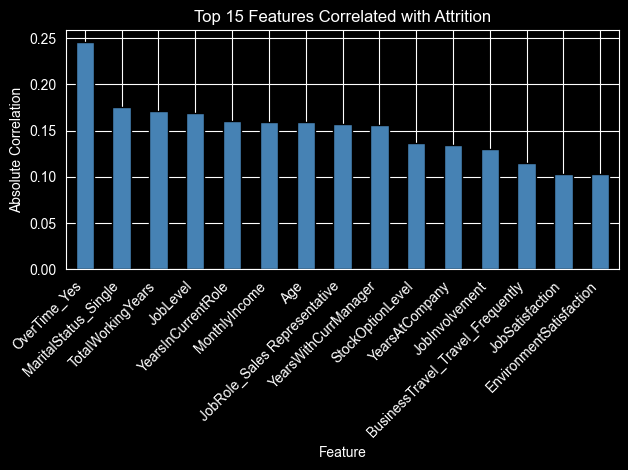

In [15]:
correlation_sorted.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Features Correlated with Attrition')
plt.ylabel('Absolute Correlation')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
top_10_features = correlation_sorted.head(10).index.tolist()

print("Selected top 10 features:")
for i, feat in enumerate(top_10_features, 1):
    print(f"  {i}. {feat}")

Selected top 10 features:
  1. OverTime_Yes
  2. MaritalStatus_Single
  3. TotalWorkingYears
  4. JobLevel
  5. YearsInCurrentRole
  6. MonthlyIncome
  7. Age
  8. JobRole_Sales Representative
  9. YearsWithCurrManager
  10. StockOptionLevel


In [19]:
df_model = df[top_10_features + ['Attrition']].copy()

print("Final model dataset shape:", df_model.shape)
df_model.head()

Final model dataset shape: (1470, 11)


,OverTime_Yes,MaritalStatus_Single,TotalWorkingYears,JobLevel,YearsInCurrentRole,MonthlyIncome,Age,JobRole_Sales Representative,YearsWithCurrManager,StockOptionLevel,Attrition
0,True,True,8,2,4,5993,41,False,5,0,1
1,False,False,10,2,7,5130,49,False,7,1,0
2,True,True,7,1,0,2090,37,False,0,0,1
3,True,False,8,1,7,2909,33,False,0,0,0
4,False,False,6,1,2,3468,27,False,2,1,0


In [21]:
# X = feature columns
X = df_model.drop('Attrition', axis=1)

# y = target column
y = df_model['Attrition']

print("Features (X) shape:", X.shape)
print("Target  (y) shape:", y.shape)
print()
print("Feature names used:")
print(X.columns.tolist())

Features (X) shape: (1470, 10)
Target  (y) shape: (1470,)

Feature names used:
['OverTime_Yes', 'MaritalStatus_Single', 'TotalWorkingYears', 'JobLevel', 'YearsInCurrentRole', 'MonthlyIncome', 'Age', 'JobRole_Sales Representative', 'YearsWithCurrManager', 'StockOptionLevel']


In [22]:
# 80% train, 20% test — stratify preserves class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)

Training set size: (1176, 10)
Testing set size:  (294, 10)


In [23]:
# Verify class ratio is preserved in both splits
print("Training set Attrition distribution:")
print(y_train.value_counts())
print()
print("Testing set Attrition distribution:")
print(y_test.value_counts())

Training set Attrition distribution:
Attrition
0    986
1    190
Name: count, dtype: int64

Testing set Attrition distribution:
Attrition
0    247
1     47
Name: count, dtype: int64


In [24]:
# Create the scaler
scaler = StandardScaler()

# Fit on training data, then scale it
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to test data (no fitting here)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape: ", X_test_scaled.shape)

Scaling complete.
X_train_scaled shape: (1176, 10)
X_test_scaled shape:  (294, 10)


In [25]:
# Apply SMOTE to the scaled training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("SMOTE applied successfully.")
print("Resampled training set shape:", X_train_resampled.shape)

SMOTE applied successfully.
Resampled training set shape: (1972, 10)


In [27]:
# Class counts before and after SMOTE
before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_train_resampled).value_counts().sort_index()

print(" Class Distribution BEFORE SMOTE")
print("=====================================")
print(f"  No Attrition (0) : {before.get(0, 0):>5} samples")
print(f"  Attrition    (1) : {before.get(1, 0):>5} samples")
print(f"  Total            : {len(y_train):>5} samples")

print()
print("=====================================")
print(" Class Distribution AFTER SMOTE")
print("=====================================")
print(f"  No Attrition (0) : {after.get(0, 0):>5} samples")
print(f"  Attrition    (1) : {after.get(1, 0):>5} samples")
print(f"  Total            : {len(y_train_resampled):>5} samples")

 Class Distribution BEFORE SMOTE
  No Attrition (0) :   986 samples
  Attrition    (1) :   190 samples
  Total            :  1176 samples

 Class Distribution AFTER SMOTE
  No Attrition (0) :   986 samples
  Attrition    (1) :   986 samples
  Total            :  1972 samples


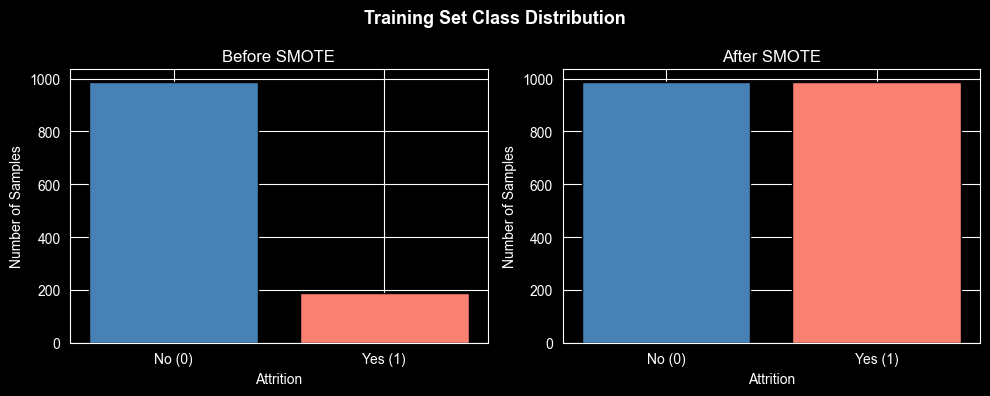

In [28]:
# Side-by-side bar chart comparing Before vs After SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
axes[0].bar(['No (0)', 'Yes (1)'],
            [before.get(0, 0), before.get(1, 0)],
            color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xlabel('Attrition')

# After SMOTE
axes[1].bar(['No (0)', 'Yes (1)'],
            [after.get(0, 0), after.get(1, 0)],
            color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Number of Samples')
axes[1].set_xlabel('Attrition')

plt.suptitle('Training Set Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

